In [ ]:
import tensorflow as tf
import os
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from keras.models import load_model


import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import cv2
import numpy as np



In [5]:
print("TensorFlow version:", tf.__version__) #Version-- 2.18
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.18.0
GPU Available: []


2025-05-21 18:02:27.126322: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# CallBacks Function

In [2]:
class SimpleCallback(tf.keras.callbacks.Callback):
    def __init__(self, patience, stop_patience, factor):
        super().__init__()
        self.patience = patience
        self.stop_patience = stop_patience
        self.factor = factor
        self.best_val_acc = -np.inf
        self.best_weights = None
        self.wait = 0
        self.stop_wait = 0

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("🚀 Training started...")

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        train_acc = logs.get("accuracy")
        val_loss = logs.get("val_loss")
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))

        print(f"📊 Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}, Val Loss = {val_loss:.4f}, LR = {lr:.6f}")

        #Training Off / On
        """response = input("❓ Continue training? (y/n): ")
        if response.lower() != 'y':
            print("⛔ Training manually stopped by user.")
            self.model.stop_training = True
            return"""

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_weights = self.model.get_weights()
            self.wait = 0
            self.stop_wait = 0
        else:
            self.wait += 1
            self.stop_wait += 1
            if self.wait >= self.patience:
                new_lr = lr * self.factor
                tf.keras.backend.set_value(self.model.optimizer.learning_rate, new_lr)
                print(f"⚠️ No improvement. Reducing LR to {new_lr:.6f}")
                self.wait = 0
            if self.stop_wait >= self.stop_patience:
                print("⛔ Training stopped (no improvement).")
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
        duration = time.time() - self.start_time
        print(f"✅ Training finished in {duration // 60:.0f}m {duration % 60:.0f}s.")


# Function to plot history of training

In [3]:
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Best epochs
    best_loss_epoch = np.argmin(val_loss) + 1
    best_acc_epoch = np.argmax(val_acc) + 1

    # Plot Loss
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'r-', label='Training Loss')
    plt.plot(epochs, val_loss, 'g-', label='Validation Loss')
    plt.scatter(best_loss_epoch, val_loss[best_loss_epoch - 1], c='blue', s=100, label=f'Best Epoch: {best_loss_epoch}')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'r-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')
    plt.scatter(best_acc_epoch, val_acc[best_acc_epoch - 1], c='blue', s=100, label=f'Best Epoch: {best_acc_epoch}')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


# Show Training Images

In [10]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

# Data Augmentaion

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
color = 'rgb'
SEED = 42

train_path = "/kaggle/input/splitted/color-split/train"
val_path = "/kaggle/input/splitted/color-split/val"
test_path = "/kaggle/input/splitted/color-split/test"


#Data Augmentation
train_datagen = ImageDataGenerator(

   # brightness_range=[0.3, 1.5],
    horizontal_flip=True,
    vertical_flip = True
)


# No Augmentation for Validation and Test
val_test_datagen = ImageDataGenerator()

# Train
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    color_mode = color,
    seed = SEED
)

# Validation
val_data = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    color_mode = color,
    seed = SEED
)

# Test
test_data = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    color_mode = color,
    seed = SEED
)

Found 43429 images belonging to 38 classes.
Found 5417 images belonging to 38 classes.
Found 5459 images belonging to 38 classes.


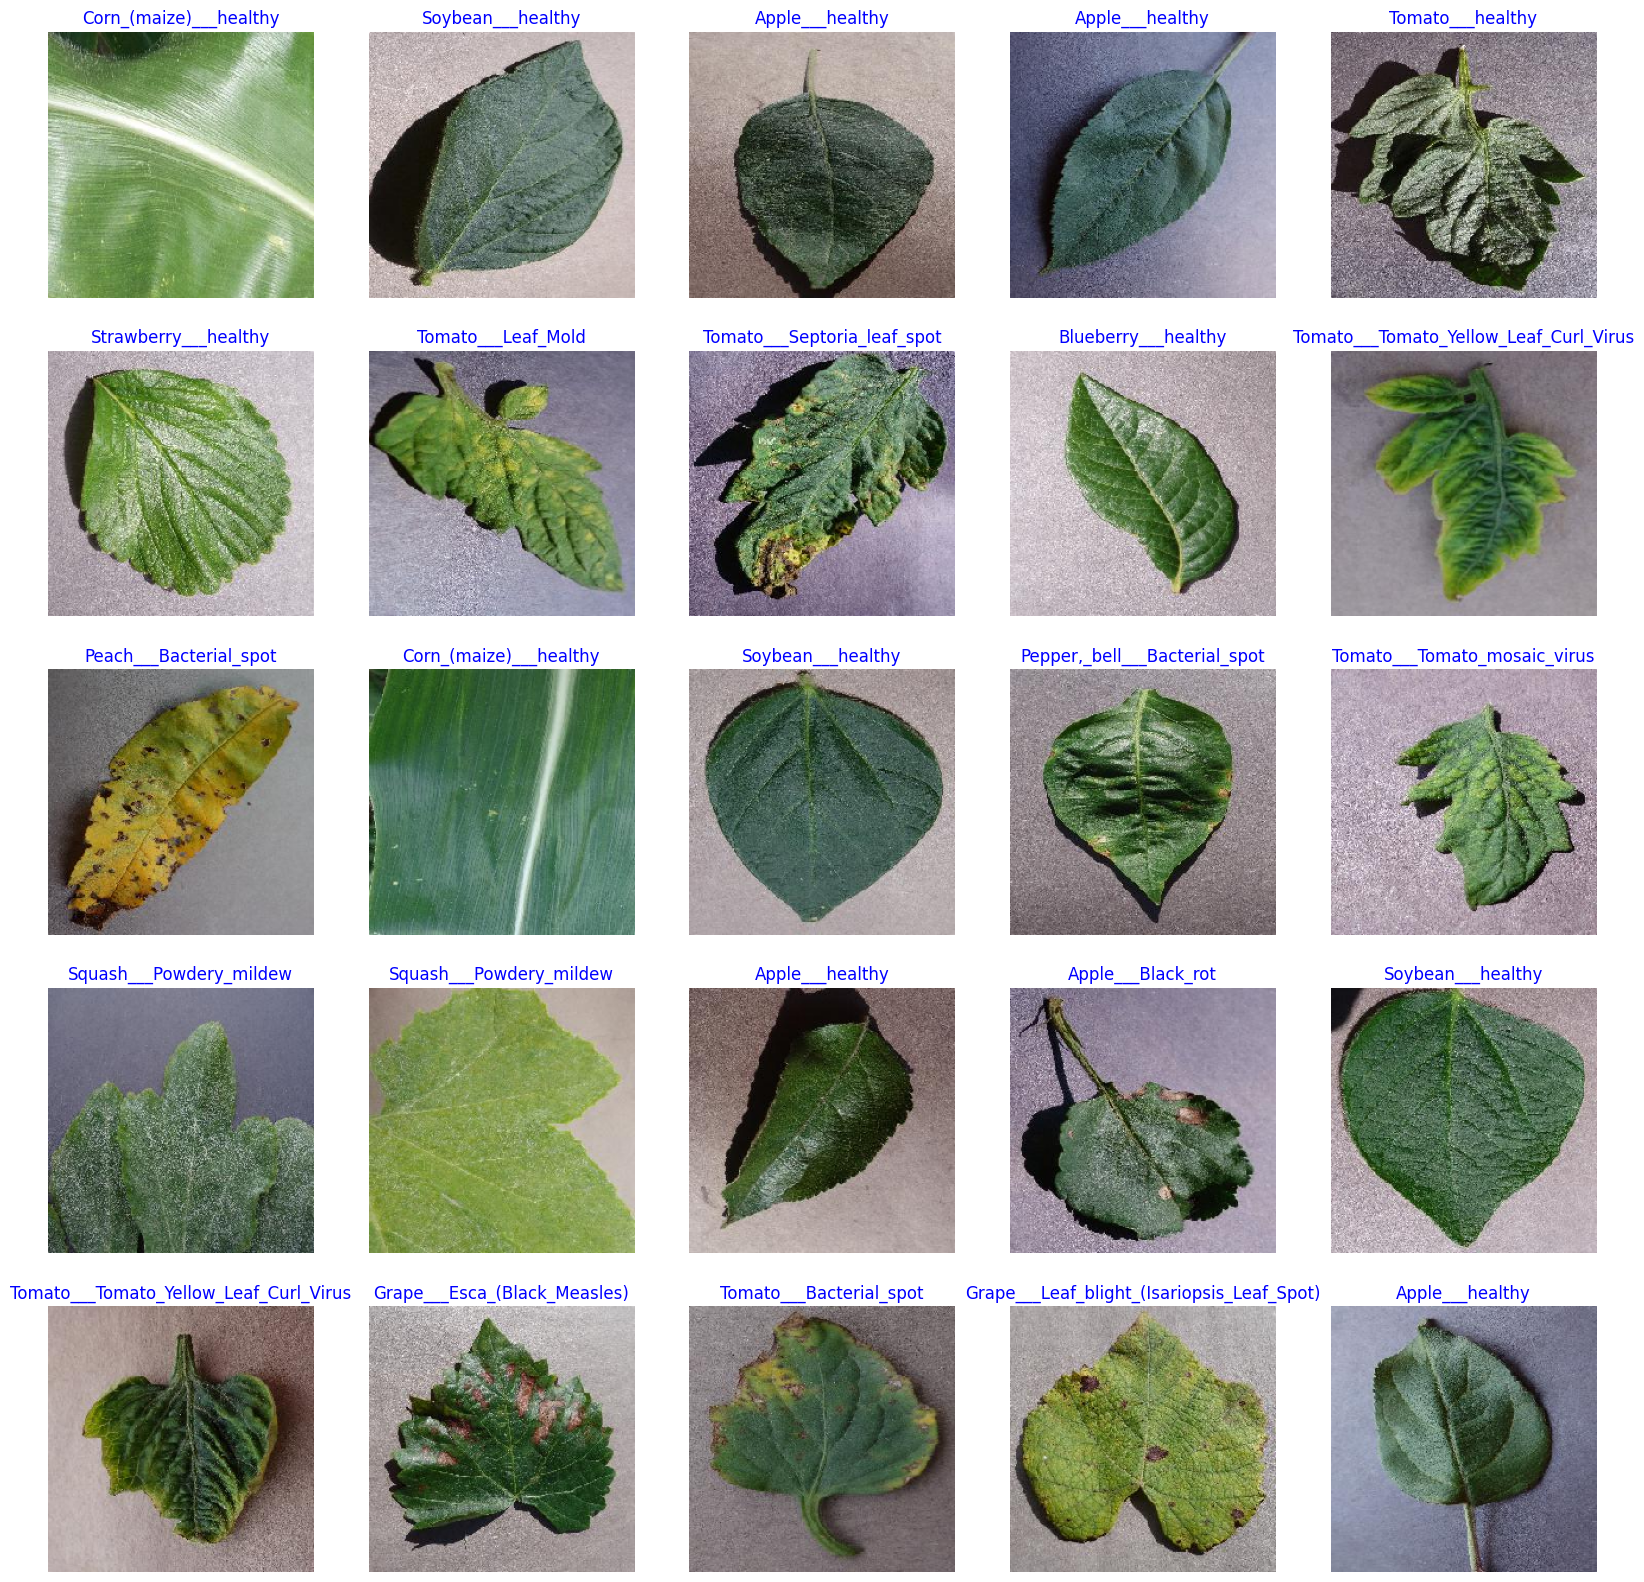

In [11]:
show_images(train_data)

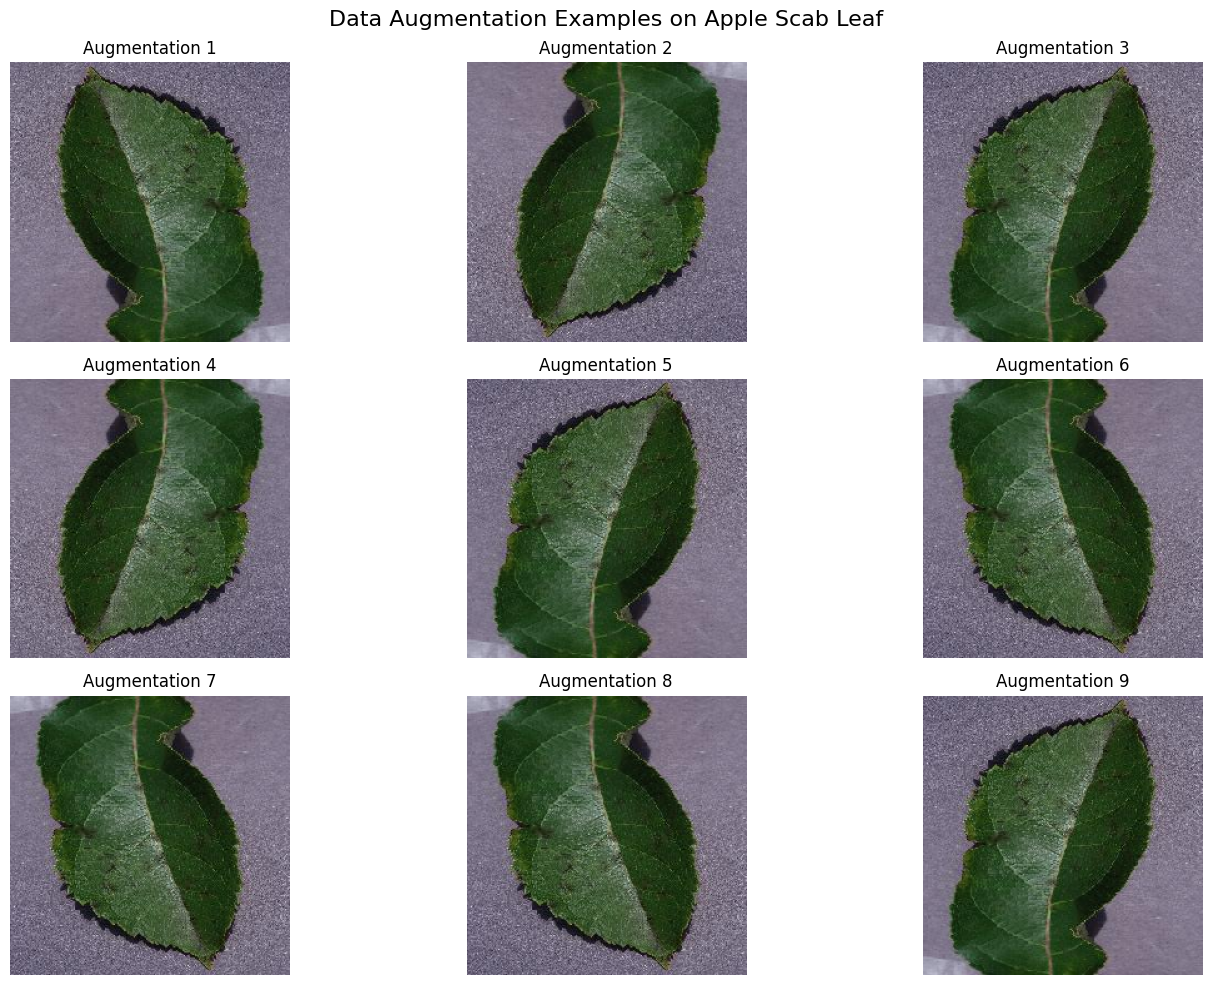

In [12]:
# 1. Load a single image
sample_image_path = "/kaggle/input/splitted/color-split/train/Apple___Apple_scab/0395b847-2c73-4674-826f-33a6afb5b4fe___FREC_Scab 3287.JPG"
img = load_img(sample_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)  # Add batch dimension

# 2. Generate augmented versions
plt.figure(figsize=(15, 10))
plt.suptitle("Data Augmentation Examples on Apple Scab Leaf", fontsize=16)

for i in range(9):  # Show 9 variations
    augmented = next(train_datagen.flow(img_array, batch_size=1))[0].astype('uint8')  # Fixed: next() instead of .next()
    
    plt.subplot(3, 3, i+1)
    plt.imshow(augmented)
    plt.title(f"Augmentation {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# CallBacks

In [13]:
# Hyperparameters
patience = 2       # Epochs to wait before reducing LR
stop_patience = 4  # Epochs to wait before early stopping
factor = 0.1      # Factor to reduce LR

# ModelCheckpoint: Save the best model based on validation accuracy
model_checkpoint_best = ModelCheckpoint(
    filepath='/kaggle/working/best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping: Stop training if validation accuracy doesn't improve
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=stop_patience,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=factor,
    patience=patience,
    mode='min',
    min_lr=1e-7,
    verbose=1
)

# Combine callbacks
callbacks = [model_checkpoint_best, early_stopping, reduce_lr]


# Training ...

# Phase 1 (Freezing)


In [14]:
# Define image size and channels
CHANNELS = 3
img_shape = (IMG_SIZE, IMG_SIZE, CHANNELS)
class_count = len(train_data.class_indices)

# Load EfficientNetB0 base model
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling = 'max'
)

base_model.trainable = False #Freeze

model = Sequential([
    base_model,
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4, seed = SEED),
    layers.Dense(class_count, activation='softmax')
])

model.summary()

I0000 00:00:1747901548.331612      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747901548.332274      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 1280)                │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          19,494 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,724,937 (18.02 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
#Checking Layers Freezed (Transfer)

for layer in base_model.layers:
    print(f"{layer.name}: {'Trainable' if layer.trainable else 'Frozen'}")


input_layer_2: Frozen
rescaling_2: Frozen
normalization_1: Frozen
rescaling_3: Frozen
stem_conv_pad: Frozen
stem_conv: Frozen
stem_bn: Frozen
stem_activation: Frozen
block1a_dwconv: Frozen
block1a_bn: Frozen
block1a_activation: Frozen
block1a_se_squeeze: Frozen
block1a_se_reshape: Frozen
block1a_se_reduce: Frozen
block1a_se_expand: Frozen
block1a_se_excite: Frozen
block1a_project_conv: Frozen
block1a_project_bn: Frozen
block2a_expand_conv: Frozen
block2a_expand_bn: Frozen
block2a_expand_activation: Frozen
block2a_dwconv_pad: Frozen
block2a_dwconv: Frozen
block2a_bn: Frozen
block2a_activation: Frozen
block2a_se_squeeze: Frozen
block2a_se_reshape: Frozen
block2a_se_reduce: Frozen
block2a_se_expand: Frozen
block2a_se_excite: Frozen
block2a_project_conv: Frozen
block2a_project_bn: Frozen
block2b_expand_conv: Frozen
block2b_expand_bn: Frozen
block2b_expand_activation: Frozen
block2b_dwconv: Frozen
block2b_bn: Frozen
block2b_activation: Frozen
block2b_se_squeeze: Frozen
block2b_se_reshape: F

In [15]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_head = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

# Save the model
#model.save('/kaggle/working/EfficientNetB0_feature_extraction.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1747901605.242050     146 service.cc:148] XLA service 0x7dd7a814ef80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747901605.242871     146 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747901605.242892     146 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747901607.104781     146 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1358 ━━━━━━━━━━━━━━━━━━━━ 1:11 53ms/step - accuracy: 0.0391 - loss: 8.6700  

I0000 00:00:1747901616.847939     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6482 - loss: 1.4446
Epoch 1: val_accuracy improved from -inf to 0.89551, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 410s 283ms/step - accuracy: 0.6483 - loss: 1.4442 - val_accuracy: 0.8955 - val_loss: 0.3111 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8455 - loss: 0.4757
Epoch 2: val_accuracy improved from 0.89551 to 0.91379, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 100s 74ms/step - accuracy: 0.8455 - loss: 0.4757 - val_accuracy: 0.9138 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8611 - loss: 0.4317
Epoch 3: val_accuracy improved from 0.91379 to 0.93927, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 98s 72ms/step - accuracy: 0.8611 - loss: 0.4316 - val_accuracy: 0.9393 - val_loss: 0.1784 - learning_rate: 

# Phase 2 (Unfreezing)

In [16]:
# Phase 2
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False 
    elif "block7" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False 


model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 1280)                │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          19,494 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,724,937 (18.02 MB)

 Trainable params: 1,387,350 (5.29 MB)

 Non-trainable params: 3,337,587 (12.73 MB)

In [9]:
#Checking Layers unfreezed (Fine-Tuning)

for layer in base_model.layers:
    print(f"{layer.name}: {'Trainable' if layer.trainable else 'Frozen'}")


input_layer_2: Frozen
rescaling_2: Frozen
normalization_1: Frozen
rescaling_3: Frozen
stem_conv_pad: Frozen
stem_conv: Frozen
stem_bn: Frozen
stem_activation: Frozen
block1a_dwconv: Frozen
block1a_bn: Frozen
block1a_activation: Frozen
block1a_se_squeeze: Frozen
block1a_se_reshape: Frozen
block1a_se_reduce: Frozen
block1a_se_expand: Frozen
block1a_se_excite: Frozen
block1a_project_conv: Frozen
block1a_project_bn: Frozen
block2a_expand_conv: Frozen
block2a_expand_bn: Frozen
block2a_expand_activation: Frozen
block2a_dwconv_pad: Frozen
block2a_dwconv: Frozen
block2a_bn: Frozen
block2a_activation: Frozen
block2a_se_squeeze: Frozen
block2a_se_reshape: Frozen
block2a_se_reduce: Frozen
block2a_se_expand: Frozen
block2a_se_excite: Frozen
block2a_project_conv: Frozen
block2a_project_bn: Frozen
block2b_expand_conv: Frozen
block2b_expand_bn: Frozen
block2b_expand_activation: Frozen
block2b_dwconv: Frozen
block2b_bn: Frozen
block2b_activation: Frozen
block2b_se_squeeze: Frozen
block2b_se_reshape: F

In [17]:
# Continue training
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

# Save the model
model.save('/kaggle/working/EfficientNetB0_fine_tuned.keras')

Epoch 1/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9426 - loss: 0.1714
Epoch 1: val_accuracy improved from 0.96585 to 0.96677, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 153s 94ms/step - accuracy: 0.9426 - loss: 0.1713 - val_accuracy: 0.9668 - val_loss: 0.0887 - learning_rate: 1.0000e-05
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9481 - loss: 0.1506
Epoch 2: val_accuracy improved from 0.96677 to 0.96769, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 100s 74ms/step - accuracy: 0.9481 - loss: 0.1506 - val_accuracy: 0.9677 - val_loss: 0.0840 - learning_rate: 1.0000e-05
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9506 - loss: 0.1464
Epoch 3: val_accuracy improved from 0.96769 to 0.97046, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 71ms/step - accuracy: 0.9506 - loss: 0.1464 - val_accuracy: 0.9705 - val_loss: 0.07

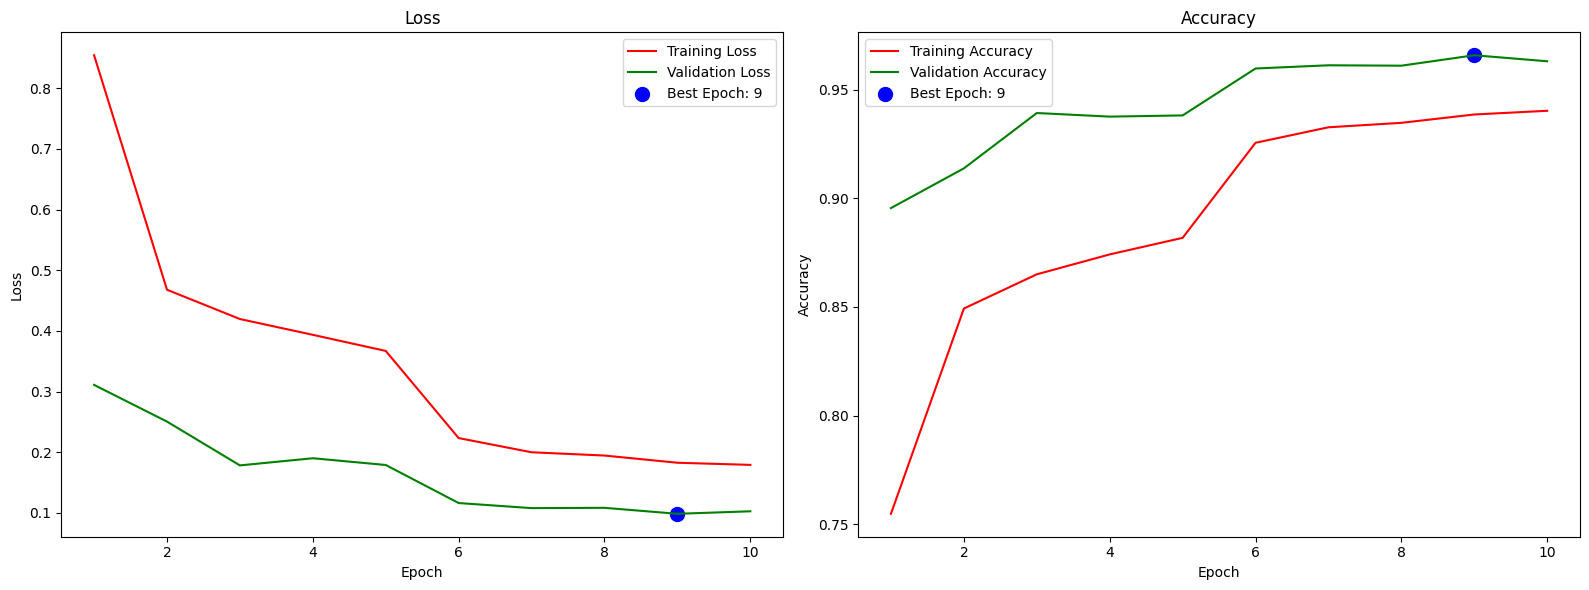

In [18]:
plot_training(history_head)

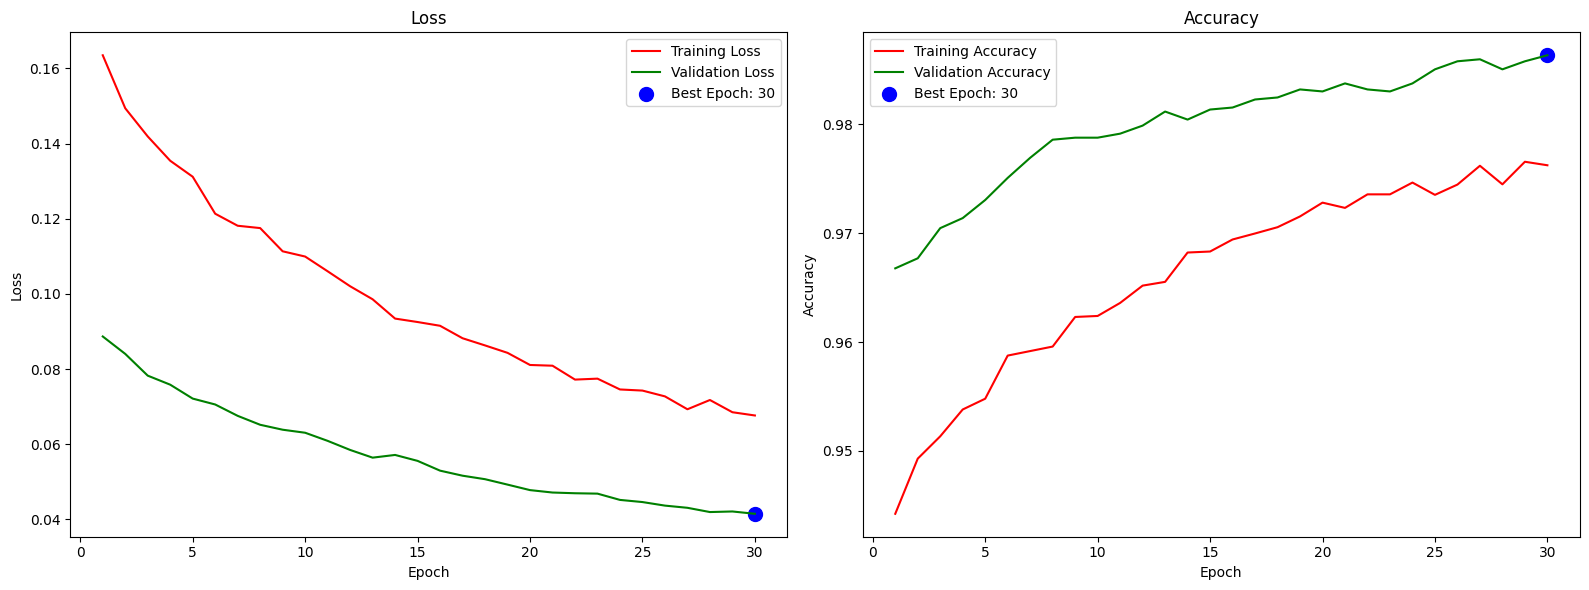

In [19]:
plot_training(history_fine)

In [21]:
train_loss, train_acc = model.evaluate(train_data, verbose=1)
val_loss,   val_acc   = model.evaluate(val_data,   verbose=1)
test_loss,  test_acc  = model.evaluate(test_data,  verbose=1)

print(f"Train Loss: {train_loss:.4f}")
print(f"Train Acc: {train_acc * 100:.2f}%")
print('-' * 20)
print(f"Val loss: {val_loss:.4f}")
print(f"Val Acc: {train_acc * 100:.2f}%")
print('-' * 20)
print(f"Test_loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc * 100:.2f}%")

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 92s 68ms/step - accuracy: 0.9944 - loss: 0.0187
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9884 - loss: 0.0344
171/171 ━━━━━━━━━━━━━━━━━━━━ 47s 277ms/step - accuracy: 0.9856 - loss: 0.0525
Train Loss: 0.0199
Train Acc: 99.38%
--------------------
Val loss: 0.0415
Val Acc: 99.38%
--------------------
Test_loss: 0.0454
Test Acc: 98.59%


In [30]:
# Get predictions
y_true = test_data.classes
y_pred_probs = model.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

171/171 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step


In [31]:
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.97      0.98        63
                                 Apple___Black_rot       0.98      0.98      0.98        63
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        28
                                   Apple___healthy       0.98      1.00      0.99       165
                               Blueberry___healthy       1.00      1.00      1.00       151
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       106
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.79      0.80        52
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       120
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.91      0.

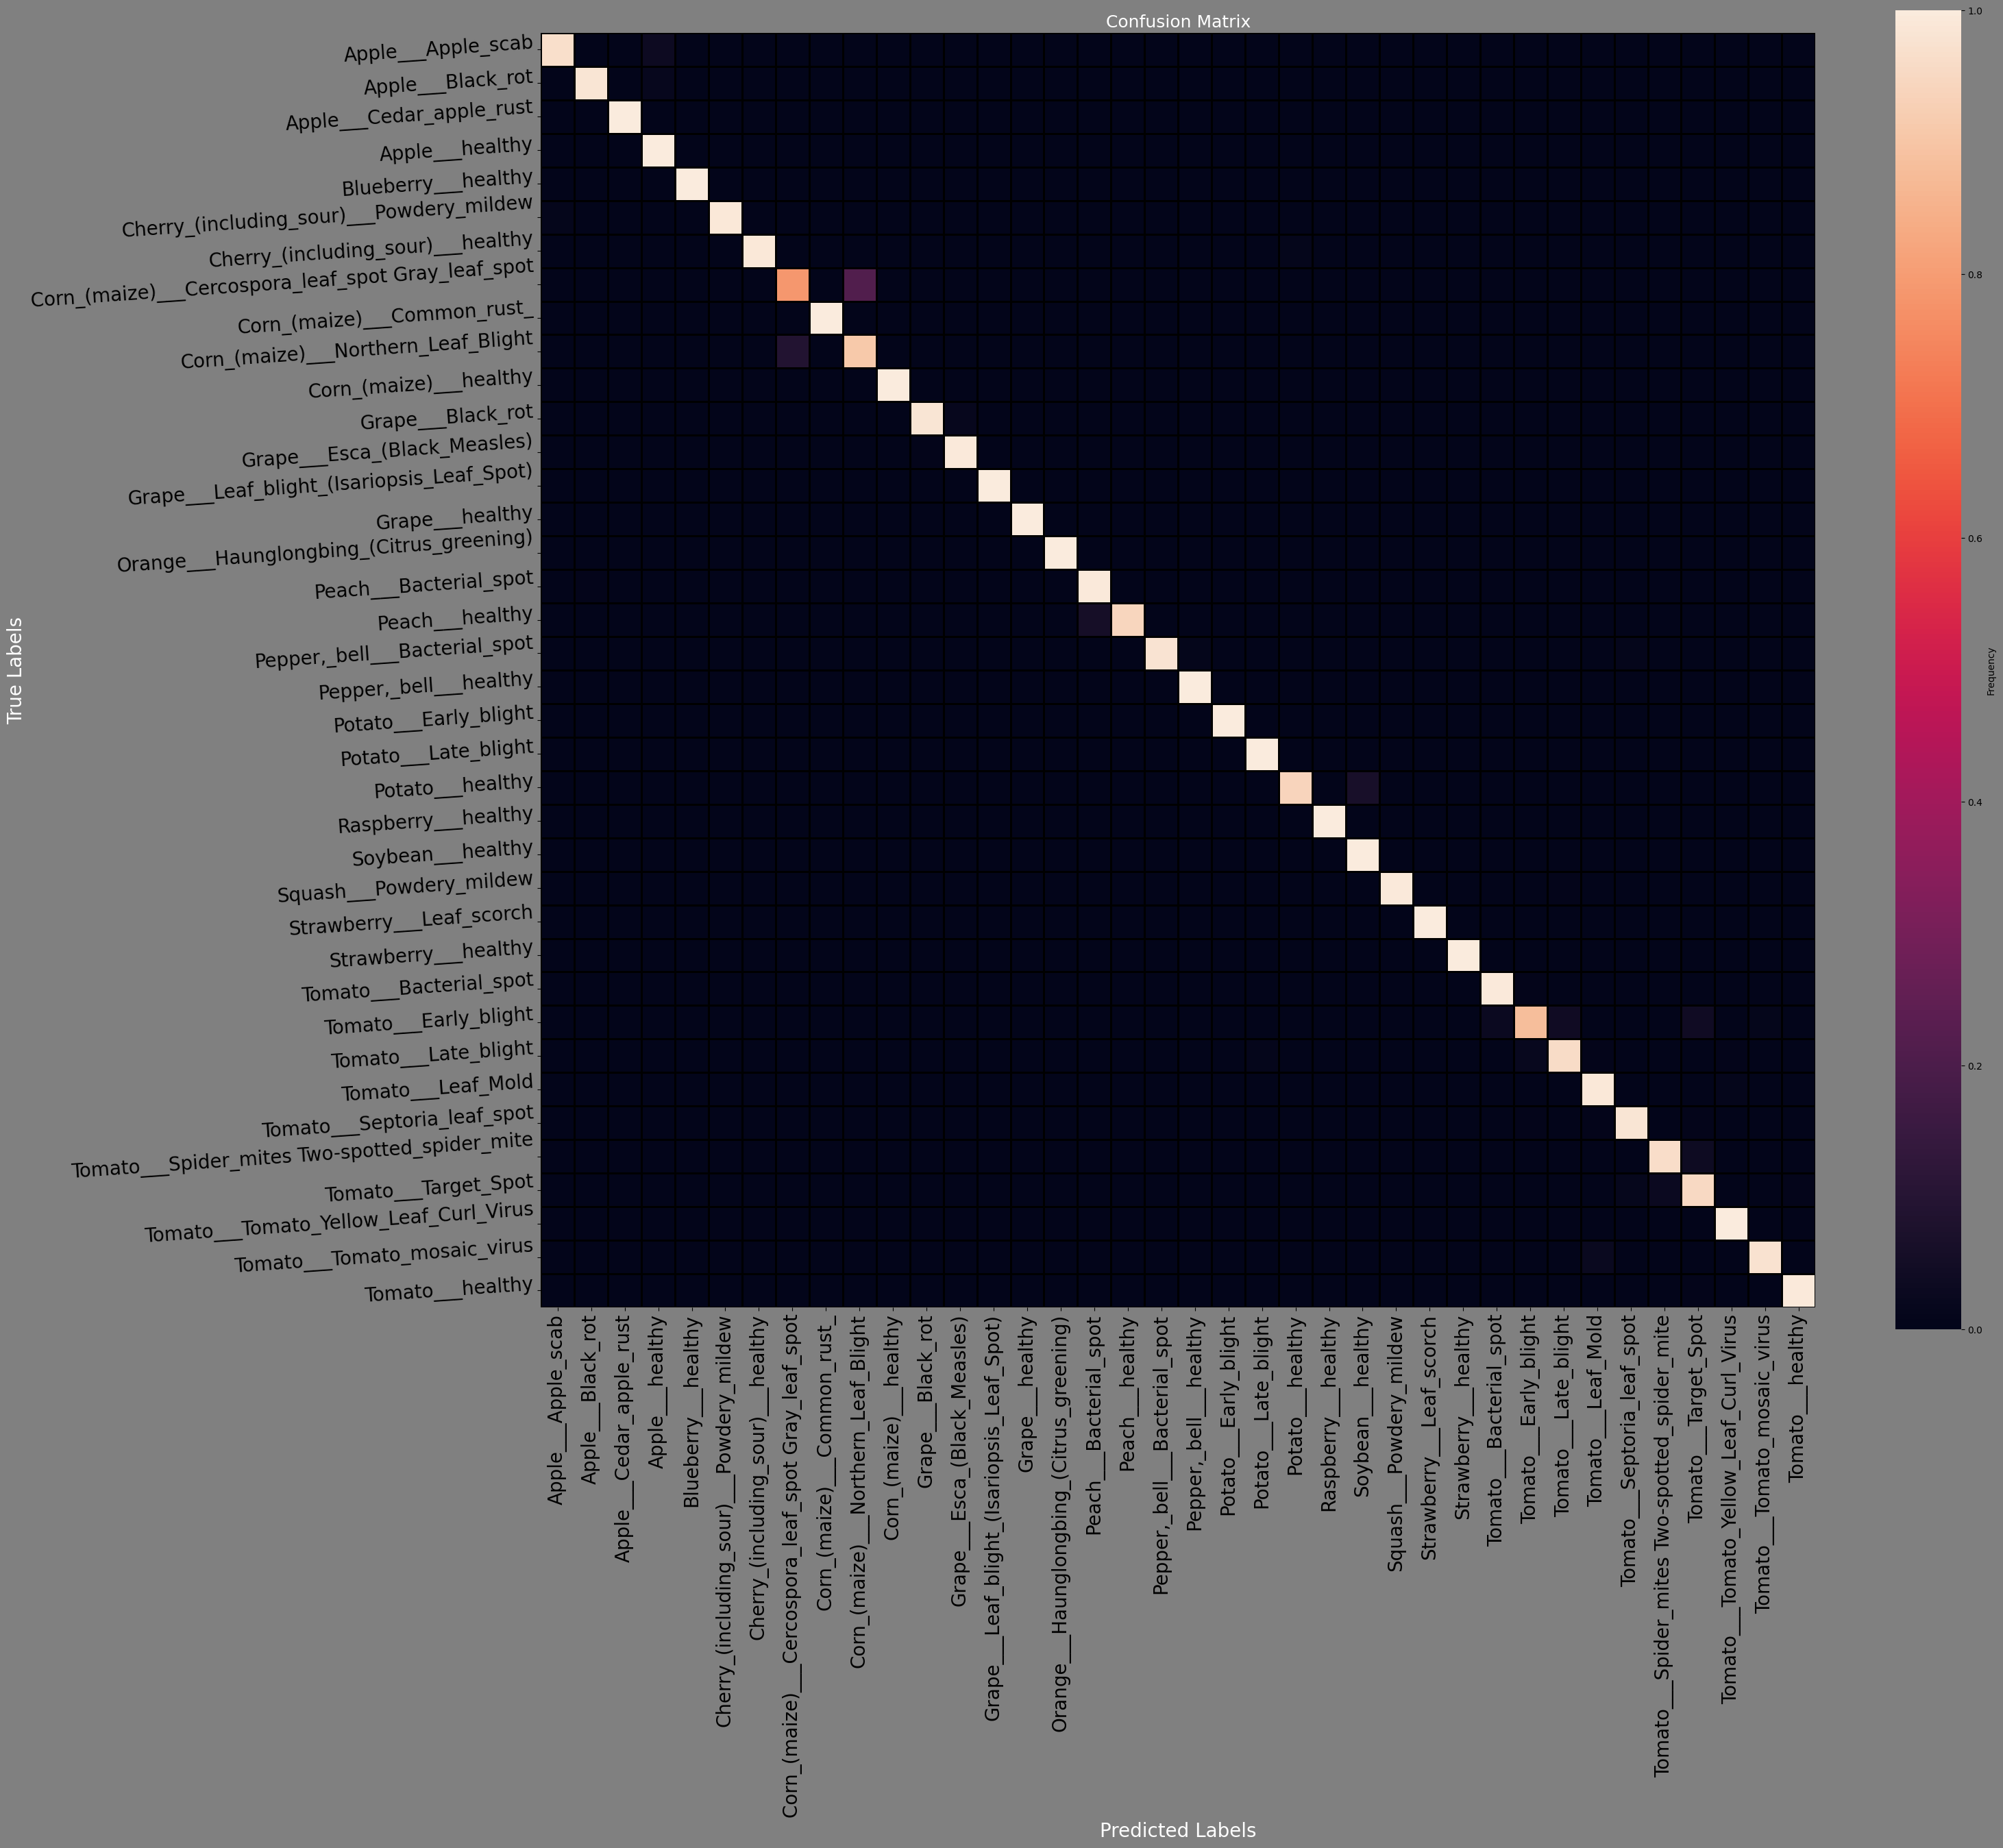

In [32]:
# Confusion matrix (real values, no normalization)
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Class names
class_names = list(train_data.class_indices.keys())
n_classes = len(class_names)

# Plot
plt.figure(figsize=(30, 25), facecolor='gray')
ax = sns.heatmap(cm_normalized, annot=False, fmt='d', cmap='rocket', 
                 xticklabels=class_names,
                 yticklabels=class_names,
                 square=True, cbar_kws={'label': 'Frequency'},
                 linewidths=2, linecolor='black')


plt.xlabel('Predicted Labels', fontsize=20, color='white')
plt.ylabel('True Labels', fontsize=20, color='white')
plt.title('Confusion Matrix', fontsize=18, color='white')


plt.xticks(rotation=90, fontsize=20, color='black')
plt.yticks(rotation=4, fontsize=20, color='black')


# Show the plot
plt.show()

In [20]:
model.save('/kaggle/working/EfficientNetB0_fine_tuned.keras')

# Testing

In [5]:
model = load_model("/kaggle/input/bestmodel2/tensorflow2/default/1/best_model2.keras")


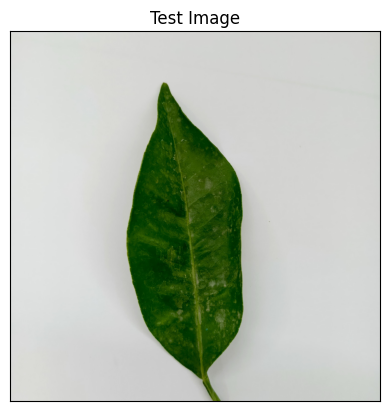

In [13]:
image_path = "/kaggle/input/ttttppp/orange2.jpeg"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [14]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(224, 224))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 224, 224, 3)


In [15]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


(array([[6.89267790e-06, 1.12836929e-09, 5.51140074e-05, 9.98569376e-05,
         3.91882770e-02, 3.39426324e-02, 1.61007591e-07, 5.09542062e-08,
         2.42135183e-11, 1.99868944e-09, 2.79119917e-07, 1.17581434e-16,
         6.81141206e-14, 1.20720982e-18, 2.11735990e-20, 8.86279523e-01,
         1.94718261e-04, 2.32476523e-04, 1.90316141e-02, 2.06618905e-02,
         6.61077486e-12, 8.98531525e-08, 7.68160874e-07, 6.63808201e-15,
         1.29811655e-08, 5.40416800e-12, 2.40741057e-16, 2.64287663e-14,
         7.29236493e-09, 1.16106129e-08, 8.22371876e-05, 1.03480579e-06,
         1.09020193e-09, 7.96254171e-05, 1.26699107e-09, 1.42913414e-04,
         3.48758156e-09, 1.03402087e-09]], dtype=float32),
 (1, 38))

In [16]:
result_index = np.argmax(prediction)
result_index

15

In [ ]:
class_names = ['Apple scab',
 'Apple Black rot',
 'Apple Cedar apple rust',
 'Apple healthy',
 'Blueberry healthy',
 'Cherry including sour Powdery mildew',
 'Cherry including sour healthy',
 'Corn maize Cercospora leaf spot Gray leaf spot',
 'Corn maize Common rust',
 'Corn maize Northern Leaf Blight',
 'Corn maize healthy',
 'Grape Black_rot',
 'Grape Esca Black Measles',
 'Grape Leaf blight Isariopsis Leaf Spot',
 'Grape healthy',
 'Orange Haunglongbing Citrus greening',
 'Peach Bacterial spot',
 'Peach healthy',
 'Pepper bell Bacterial spot',
 'Pepper bell healthy',
 'Potato Early blight',
 'Potato Late blight',
 'Potato healthy',
 'Raspberry healthy',
 'Soybean healthy',
 'Squash Powdery mildew',
 'Strawberry Leaf scorch',
 'Strawberry healthy',
 'Tomato Bacterial spot',
 'Tomato Early blight',
 'Tomato Late blight',
 'Tomato Leaf Mold',
 'Tomato Septoria leaf spot',
 'Tomato Spider mites Two spotted spider mite',
 'Tomato Target Spot',
 'Tomato Tomato Yellow Leaf Curl Virus',
 'Tomato Tomato mosaic virus',
 'Tomato healthy']

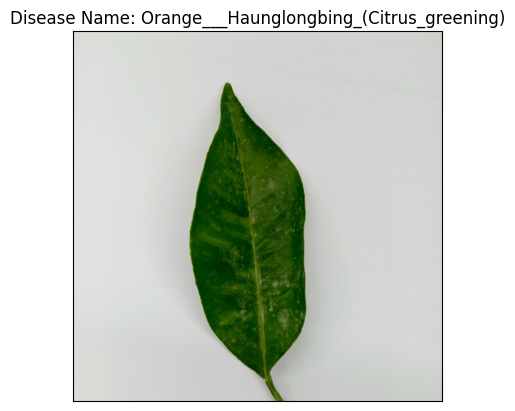

In [18]:
#Displaying Result of disease prediction
model_prediction = class_names[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
confidence = np.max(prediction)
print("Prediction:",model_prediction)
print(f"Confidence: {confidence:.2%}")

Prediction: Apple___healthy
Confidence: 90.40%


In [4]:

model = load_model('/kaggle/input/bestmodel2/tensorflow2/default/1/best_model2.keras')
IMG_SIZE = 224  
TARGET_FOLDER = "/kaggle/input/splitted/color-split/test/Potato___healthy" 

results = []

# Loop through just this folder
for file_name in os.listdir(TARGET_FOLDER):
    if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(TARGET_FOLDER, file_name)

        # Load and preprocess image
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image = tf.keras.preprocessing.image.load_img(image_path,target_size=(224, 224))
        input_arr = tf.keras.preprocessing.image.img_to_array(image)
        input_arr = np.array([input_arr]) #Convert single image to a batch
        print(input_arr.shape)

        # Predict
        preds = model.predict(input_arr, verbose=1)[0]
        pred_idx = np.argmax(preds)
        pred_label = class_names[pred_idx]
        confidence = preds[pred_idx]

        # Save result
        results.append({
            "File Name": file_name,
            "Predicted Class": pred_label,
            "Confidence": float(confidence)
        })

# DataFrame
df_results = pd.DataFrame(results)
df_results


(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


,File Name,Predicted Class,Confidence
0,b4031970-60ea-4739-9fed-6c81be1bad1c___RS_HL 1...,Potato___healthy,0.918363
1,3a1dbeee-089c-43f0-8f51-a92d3687a515___RS_HL 1...,Potato___healthy,0.998229
2,1106c3fc-92cb-41a6-a6c6-8f08b9b45108___RS_HL 1...,Potato___healthy,0.999654
3,e693354a-053c-4093-8642-cc8f5f9eb2cc___RS_HL 1...,Potato___healthy,0.999559
4,d287be3d-cac6-4485-8c31-674fb8b459be___RS_HL 1...,Potato___healthy,0.999887
5,5e19b1f4-fd65-4c4d-bcd2-18c8c519eddb___RS_HL 1...,Potato___healthy,0.997180
6,2dee1571-ef6b-40ef-8c46-334e89aad3f1___RS_HL 1...,Potato___healthy,0.999936
7,23f4d3b1-23f4-43fb-96c2-dae37224ec74___RS_HL 1...,Potato___healthy,0.996810
8,30126310-39de-4c02-b10a-23409417a4f6___RS_HL 1...,Potato___healthy,0.997011
9,23f1ab77-d664-49c4-92eb-41eb66c6d101___RS_HL 4...,Soybean___healthy,0.964901
